In [1]:
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# E-commerce Analytics Project: Sales Trends & Customer Insights

## 1. Project Overview

This project applies exploratory data analysis (EDA) techniques using Python to analyse real-world e-commerce data from a Brazilian online marketplace.

The objective is to identify patterns in sales performance, customer behaviour, and revenue drivers, and to translate these findings into actionable business insights. The analysis focuses on how different factors such as customers, products, and transaction values contribute to overall business performance.

This project demonstrates foundational data analysis skills, including data cleaning, aggregation, and visualisation, and demonstrates my preparation for further study in Data Science and AI.

---

## 2. Problem Statement

E-commerce businesses generate large volumes of transactional data, but extracting meaningful insights from this data can be challenging without structured analysis.

The aim of this project is to explore the dataset to answer key business questions, including:

- Who are the top customers contributing to revenue?
- How is revenue distributed across customers and products?
- What patterns can be observed in sales performance over time?

By addressing these questions, this project demonstrates how data-driven insights can support more informed decision-making in areas such as customer retention, marketing strategy, and operational efficiency.

## 3. Dataset Overview

The dataset used in this project is sourced from a Brazilian e-commerce platform and includes multiple tables containing information about orders, customers, products, and payments.

Key datasets used in this analysis include:

- Orders dataset: contains information on order status, purchase timestamps, and delivery details  
- Order items dataset: includes product prices and freight costs  
- Customers dataset: provides customer-level information  
- Products dataset: contains product categories and attributes  

These datasets are combined to enable a comprehensive analysis of sales performance and customer behaviour.

In [3]:
import pandas as pd
import os

base_path = "/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce"

print(os.listdir(base_path))



['olist_customers_dataset.csv', 'olist_sellers_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_order_items_dataset.csv', 'olist_products_dataset.csv', 'olist_geolocation_dataset.csv', 'product_category_name_translation.csv', 'olist_orders_dataset.csv', 'olist_order_payments_dataset.csv']


## 4. Data Loading

The main datasets were loaded successfully from the Kaggle input directory. A preview of the orders table provides an initial view of the structure of the data.

In [4]:
import pandas as pd

base_path = "/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce"

orders = pd.read_csv(f"{base_path}/olist_orders_dataset.csv")
order_items = pd.read_csv(f"{base_path}/olist_order_items_dataset.csv")
customers = pd.read_csv(f"{base_path}/olist_customers_dataset.csv")
products = pd.read_csv(f"{base_path}/olist_products_dataset.csv")
reviews = pd.read_csv(f"{base_path}/olist_order_reviews_dataset.csv") 

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


The main datasets were successfully loaded, including orders, order items, customers, and products. A preview of the orders dataset provides an initial understanding of the data structure.

In [5]:
print("Orders dataset shape:", orders.shape)
print("Order items dataset shape:", order_items.shape)
print("Customers dataset shape:", customers.shape)
print("Products dataset shape:", products.shape)

Orders dataset shape: (99441, 8)
Order items dataset shape: (112650, 7)
Customers dataset shape: (99441, 5)
Products dataset shape: (32951, 9)


The dataset dimensions show the number of rows and columns in each table. This helps to understand the scale of the data and confirms that the datasets have been loaded correctly.

## 5. Data Cleaning

Before analysis, the datasets are checked for missing values, duplicated records, and data types to ensure they are suitable for further exploration.

In [6]:
print("Orders missing values:")
print(orders.isnull().sum())

print("\nOrder items missing values:")
print(order_items.isnull().sum())

print("\nCustomers missing values:")
print(customers.isnull().sum())

print("\nProducts missing values:")
print(products.isnull().sum())

Orders missing values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Order items missing values:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Customers missing values:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Products missing values:
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm      

In [7]:
print("Orders duplicates:", orders.duplicated().sum())
print("Order items duplicates:", order_items.duplicated().sum())
print("Customers duplicates:", customers.duplicated().sum())
print("Products duplicates:", products.duplicated().sum())

Orders duplicates: 0
Order items duplicates: 0
Customers duplicates: 0
Products duplicates: 0


In [8]:
orders.info()
order_items.info()
customers.info()
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 

The data quality checks provide an overview of missing values, duplicate records, and variable types. These checks are important for identifying any issues that may affect the reliability of the analysis.

## 6. Feature Engineering

To support the analysis, a revenue variable is created using product price and freight value. The relevant datasets are then merged to enable customer-level analysis.

In [9]:
df = order_items.merge(orders, on="order_id", how="left")
df = df.merge(customers, on="customer_id", how="left")
df = df.merge(products, on="product_id", how="left")
df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,customer_city,customer_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,campos dos goytacazes,RJ,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,santa fe do sul,SP,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,para de minas,MG,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,atibaia,SP,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,varzea paulista,SP,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0


In [10]:
df["revenue"] = df["price"] + df["freight_value"]
df[["price", "freight_value", "revenue"]].head()

,price,freight_value,revenue
0,58.90,13.29,72.19
1,239.90,19.93,259.83
2,199.00,17.87,216.87
3,12.99,12.79,25.78
4,199.90,18.14,218.04


In [11]:
if "review_score" not in df.columns:
    df = df.merge(reviews[["order_id", "review_score"]], on="order_id", how="left")

In [12]:
df.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value', 'customer_id',
       'order_status', 'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm', 'revenue',
       'review_score'],
      dtype='object')

The merged dataset combines order, customer, product, and review information into a single table. This allows for comprehensive analysis across different dimensions, including revenue, customer behaviour, product performance, and customer satisfaction.

## 7. Exploratory Data Analysis

This section explores key patterns in sales performance, customer behaviour, and product-level trends using exploratory data analysis techniques.


### 7.1 Orders Over Time

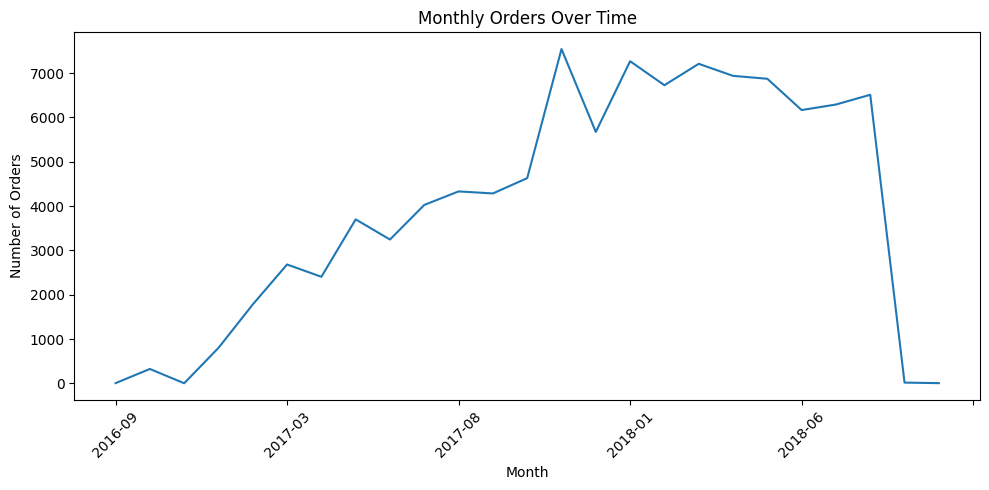

In [13]:
import matplotlib.pyplot as plt


orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])


orders["order_month"] = orders["order_purchase_timestamp"].dt.to_period("M")


monthly_orders = orders.groupby("order_month").size()


monthly_orders.index = monthly_orders.index.astype(str)


plt.figure(figsize=(10,5))
monthly_orders.plot()

plt.title("Monthly Orders Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("monthly_orders.png", dpi=300, bbox_inches="tight")

plt.show()


The overall upward trend suggests sustained growth in customer demand over time. While a sharp decline appears in the final month, this is likely due to incomplete data coverage rather than a true drop in orders, highlighting the importance of considering data limitations when interpreting trends.

### 7.2 Revenue Distribution

This section examines how revenue is distributed across transactions to understand whether most orders are low-value, high-value, or concentrated in a smaller number of purchases.

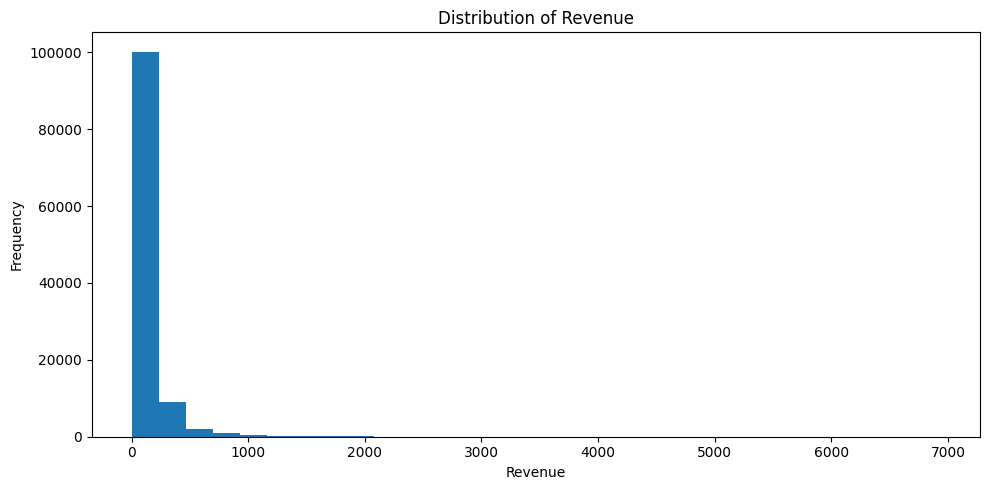

In [14]:
plt.figure(figsize=(10,5))

df["revenue"].plot(kind="hist", bins=30)

plt.title("Distribution of Revenue")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("revenue_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

The revenue distribution appears right-skewed, indicating that most transactions are relatively low in value, while a smaller number of high-value orders contribute disproportionately to total revenue. This suggests that revenue is not evenly distributed across transactions.

### 7.3 Top Products by Revenue

This section identifies the top-performing products based on total revenue, helping to understand which product categories contribute most to overall sales.

In [15]:
top_products = (
    df.groupby("product_category_name")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

product_category_name
beleza_saude              1446622.08
relogios_presentes        1306761.40
cama_mesa_banho           1258189.51
esporte_lazer             1163329.98
informatica_acessorios    1068070.48
moveis_decoracao           910683.05
utilidades_domesticas      781170.03
cool_stuff                 721492.90
automotivo                 687374.19
ferramentas_jardim         585646.54
Name: revenue, dtype: float64

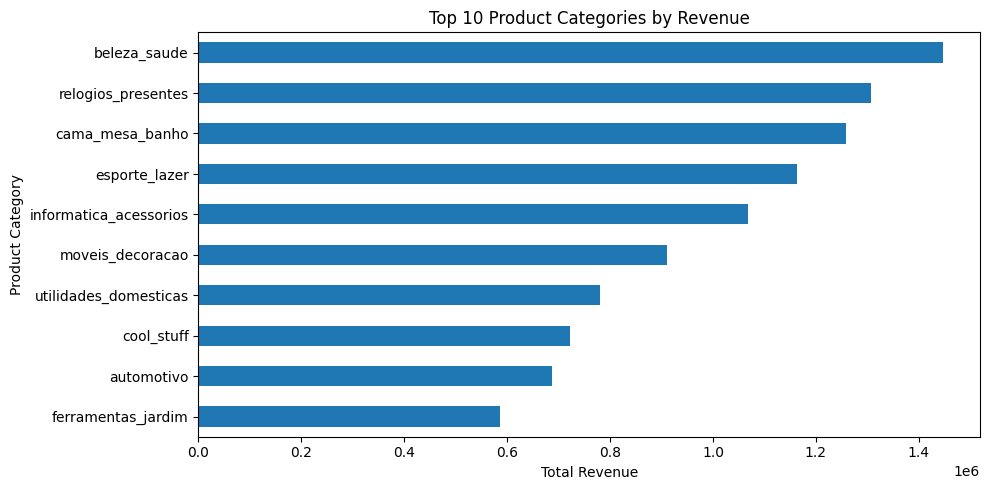

In [16]:
plt.figure(figsize=(10,5))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product Category")
plt.tight_layout()
plt.savefig("top_product_categories.png", dpi=300, bbox_inches="tight")

plt.show()

The analysis shows that a small number of product categories contribute a significant proportion of total revenue. This indicates that sales performance is concentrated in specific categories, suggesting that these products play a key role in overall business success.

### 7.4 Customer Satisfaction Analysis

This section analyses customer satisfaction using review scores to understand how customers rate their purchasing experience.

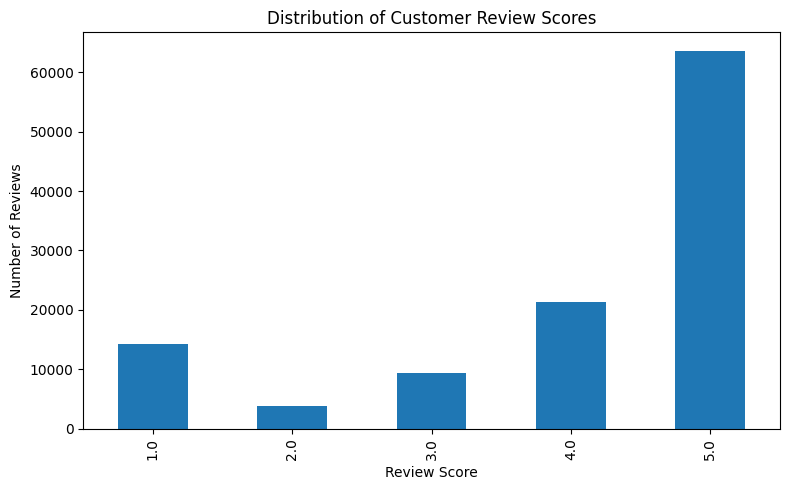

In [17]:
plt.figure(figsize=(8,5))

df["review_score"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Customer Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.savefig("review_score_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

The distribution is skewed toward higher ratings, with most customers giving scores of 4 or 5. This indicates a high level of overall customer satisfaction, although the smaller number of low ratings suggests variability in customer experience.

### 7.5 Customer Satisfaction by Order Status

This section examines how customer satisfaction varies across different order statuses to understand how delivery outcomes influence customer reviews.

In [18]:
avg_review_by_status = (
    df.groupby("order_status")["review_score"]
    .mean()
    .sort_values(ascending=False)
)

avg_review_by_status

order_status
delivered      4.081309
approved       2.000000
shipped        1.997297
invoiced       1.650838
canceled       1.593573
unavailable    1.571429
processing     1.340909
Name: review_score, dtype: float64

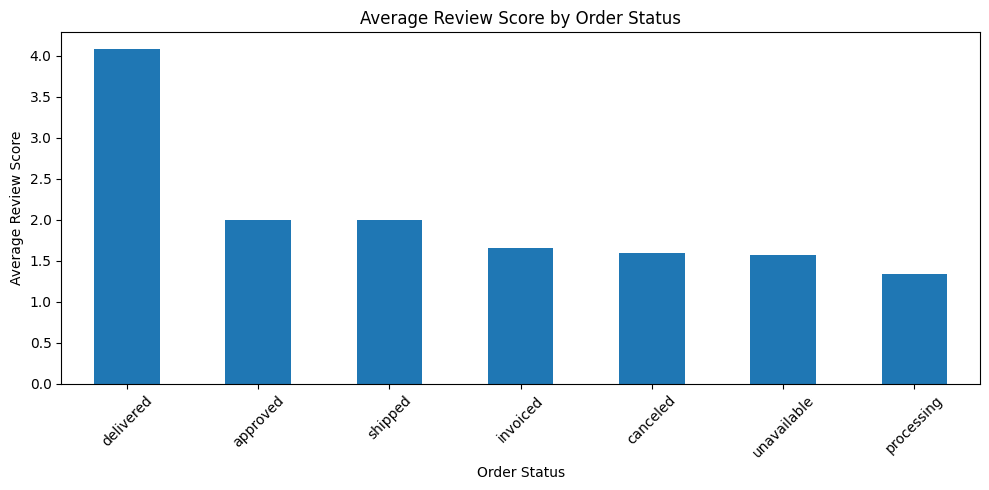

In [19]:
plt.figure(figsize=(10,5))

avg_review_by_status.plot(kind="bar")

plt.title("Average Review Score by Order Status")
plt.xlabel("Order Status")
plt.ylabel("Average Review Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("review_by_status.png", dpi=300, bbox_inches="tight")

plt.show()

The variation in average review scores across order statuses indicates that customer satisfaction is closely linked to the outcome of the order. Successfully completed orders are associated with higher ratings, while unsuccessful or delayed orders tend to receive lower scores, highlighting the importance of reliable operations.

### 7.6 Top Customers by Revenue

This section identifies the highest-value customers based on total revenue contribution, helping to understand how revenue is distributed across the customer base.

In [20]:
top_customers = (
    df.groupby("customer_unique_id")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

customer_unique_id
0a0a92112bd4c708ca5fde585afaa872    13664.08
da122df9eeddfedc1dc1f5349a1a690c     7571.63
763c8b1c9c68a0229c42c9fc6f662b93     7274.88
dc4802a71eae9be1dd28f5d788ceb526     6929.31
459bef486812aa25204be022145caa62     6922.21
ff4159b92c40ebe40454e3e6a7c35ed6     6726.66
4007669dec559734d6f53e029e360987     6081.54
5d0a2980b292d049061542014e8960bf     4809.44
eebb5dda148d3893cdaf5b5ca3040ccb     4764.34
48e1ac109decbb87765a3eade6854098     4681.78
Name: revenue, dtype: float64

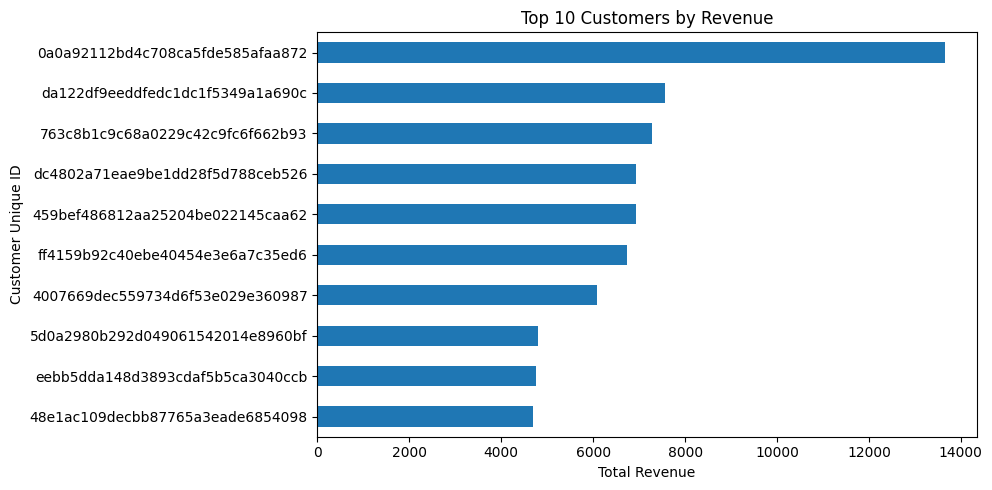

In [21]:
plt.figure(figsize=(10,5))

top_customers.sort_values().plot(kind="barh")

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Customer Unique ID")
plt.tight_layout()
plt.savefig("top_customers.png", dpi=300, bbox_inches="tight")

plt.show()

The results show that a small number of customers contribute a disproportionately large share of total revenue. This indicates a concentration of revenue among high-value customers, which could be important for customer retention strategies.

## 8. Key Insights

- **Revenue is concentrated among a small number of customers**  
  A relatively small group of high-value customers contributes a disproportionate share of total revenue. This highlights the importance of identifying and retaining these customers to sustain business performance.

- **Most transactions are low-value, with a small number of high-value orders**  
  The revenue distribution is right-skewed, indicating that while most purchases are relatively low in value, a small number of large transactions significantly impact total revenue.

- **Sales performance is driven by a limited number of product categories**  
  A small number of product categories generate a large share of revenue, suggesting that business performance is highly dependent on key product segments.

- **Customer satisfaction is generally high**  
  The majority of customers give review scores of 4 and 5, indicating strong overall satisfaction with the purchasing experience.

- **Customer satisfaction is influenced by order outcomes**  
  Orders that are successfully delivered tend to receive higher review scores, while cancelled or problematic orders are associated with lower satisfaction levels. This highlights the importance of reliable delivery and operational efficiency.

- **Order volume has increased over time**  
  The number of orders shows a clear upward trend, suggesting growing customer demand and platform adoption over the observed period.

  These insights are particularly relevant to e-commerce businesses, where understanding customer behaviour, product performance, and satisfaction is essential for driving growth and improving customer retention.

  ## 9. Business Recommendations

- **Develop targeted retention strategies for high-value customers**  
  Since revenue is concentrated among a small group of customers, businesses should focus on retaining these high-value customers through personalised marketing, loyalty programmes, exclusive offers, and community-driven initiatives such as events and brand experiences. These activities can strengthen customer relationships, increase engagement, and encourage repeat purchases.

- **Optimise product strategy around top-performing categories**  
  A limited number of product categories generate the majority of revenue. Businesses should prioritise inventory management, marketing efforts, and product development within these high-performing segments. In addition, implementing targeted actions such as merchandising optimisation, bundling complementary products, and promotional campaigns can further enhance the sales performance of top products and improve overall revenue generation.

- **Improve operational performance to enhance customer satisfaction**  
  Customer satisfaction is closely linked to order outcomes. Ensuring reliable delivery, minimising delays, and reducing order cancellations can significantly improve customer experience and review scores. In addition, implementing AI-powered customer support tools (such as chatbots) to provide real-time order tracking and enquiry handling can further enhance the customer experience by improving responsiveness and reducing uncertainty during the purchase and delivery process.

- **Leverage data to identify and support growth opportunities**  
  The increasing trend in order volume suggests growing customer demand. Businesses should use data-driven insights to identify emerging trends, optimise marketing strategies, and support expansion into high-potential product categories or customer segments.

- **Address lower satisfaction segments to reduce negative experiences**  
  Although overall customer satisfaction is high, lower review scores indicate areas for improvement. Analysing the root causes of negative experiences such as delivery delays or product issues can help businesses refine processes, reduce churn, and improve long-term customer retention.

These recommendations demonstrate how data-driven insights can be translated into practical business strategies, highlighting the value of data analysis in supporting decision-making and improving overall business performance.

## 10. Limitations and Future Work

This analysis is limited to exploratory analysis of historical transactional data and does not include predictive or causal modelling. In addition, some insights may be affected by data limitations, such as missing values and incomplete time coverage.

Future work could extend this project by applying machine learning techniques, such as customer segmentation, demand forecasting, and predictive modelling. These approaches would enable deeper insights into customer behaviour and support more advanced, data-driven decision-making in e-commerce.

This progression reflects the transition from descriptive analytics to predictive and prescriptive modelling, which is a key focus of advanced study in Data Science and AI.